In [1]:
import pandas as pd
import numpy as np

# Load dataset

In [ ]:
df = pd.read_csv('data/raw_data.csv', sep=';', encoding='utf-8')
df.head(5)

,region,departement,Mois,Nombre d'allocataires pris en charge,Nombre d'ouvertures de droit,Nombre d'ouvertures de droit initiales,Nombre de reprises,Nombre de fins de droit,Montant d'allocation journalier,Durée moyenne potentielle,...,Nombre d'allocataires indemnisés au titre de l'ASP,Montant moyen d'indemnisation mensuel net,Montant moyen d'indemnisation mensuel net des allocataires ayant travaillé,Montant moyen d'indemnisation mensuel net des allocataires n'ayant pas travaillé,Part des allocataires ayant travaillé dans le mois,Part des allocataires ayant travaillé dans le mois ét ayant été indemnisé,Dépense mensuelle,code_departement,geo_departement,geo_centre
0,Auvergne-Rhône-Alpes,01 - Ain,2020-01,36281.0,2134.0,1573.0,1261.0,627.0,45.4,552.0,...,465.0,1057.645441,739.179632,1215.104722,0.456548,0.248394,32658994.48,01,"{""coordinates"": [[[[5.310626642, 46.446940749]...","46.099767373, 5.348727908"
1,Auvergne-Rhône-Alpes,01 - Ain,2020-04,39440.0,1602.0,1525.0,1170.0,NaN,46.4,576.0,...,443.0,1081.241436,811.678102,1159.762211,0.323631,0.185674,38315683.72,01,"{""coordinates"": [[[[5.310626642, 46.446940749]...","46.099767373, 5.348727908"
2,Auvergne-Rhône-Alpes,01 - Ain,2020-10,38099.0,2153.0,1650.0,1134.0,565.0,43.3,548.0,...,541.0,1101.991684,773.832016,1254.894939,0.465813,0.230557,33888351.63,01,"{""coordinates"": [[[[5.310626642, 46.446940749]...","46.099767373, 5.348727908"
3,Auvergne-Rhône-Alpes,01 - Ain,2021-02,39912.0,1309.0,1214.0,895.0,NaN,47.1,581.0,...,577.0,1029.528641,733.226043,1150.863362,0.443275,0.214171,33435404.90,01,"{""coordinates"": [[[[5.310626642, 46.446940749]...","46.099767373, 5.348727908"
4,Auvergne-Rhône-Alpes,01 - Ain,2021-07,36963.0,4223.0,1652.0,1313.0,3640.0,39.6,488.0,...,463.0,1114.142275,789.215827,1277.058258,0.495793,0.228769,31786419.31,01,"{""coordinates"": [[[[5.310626642, 46.446940749]...","46.099767373, 5.348727908"


In [5]:
df.shape

(7371, 22)

In [168]:
print("\nCheck datatype:")
display(pd.DataFrame( df.dtypes.astype(str)))



Check datatype:


,0
region,object
departement,object
Mois,object
Nombre d'allocataires pris en charge,float64
Nombre d'ouvertures de droit,float64
Nombre d'ouvertures de droit initiales,float64
Nombre de reprises,float64
Nombre de fins de droit,float64
Montant d'allocation journalier,float64
Durée moyenne potentielle,float64


# Data Cleaning

In [169]:
 
df = df.drop_duplicates() # remove duplicate values

In [170]:
df['Mois'] = pd.to_datetime(df['Mois'], errors='coerce') # convert the object to datatime for the col "mois"

In [171]:
df.drop(columns=['geo_departement', 'geo_centre'], inplace=True, errors='ignore') # remove the cold unnecessary

In [172]:
# switch to category (helps reduce memory and speed up groupby)
df[['region', 'departement']] = df[['region', 'departement']].astype('category')
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

In [173]:
display(pd.DataFrame( df.dtypes.astype(str)))

,0
region,category
departement,category
Mois,datetime64[ns]
Nombre d'allocataires pris en charge,float64
Nombre d'ouvertures de droit,float64
Nombre d'ouvertures de droit initiales,float64
Nombre de reprises,float64
Nombre de fins de droit,float64
Montant d'allocation journalier,float64
Durée moyenne potentielle,float64


<Axes: >

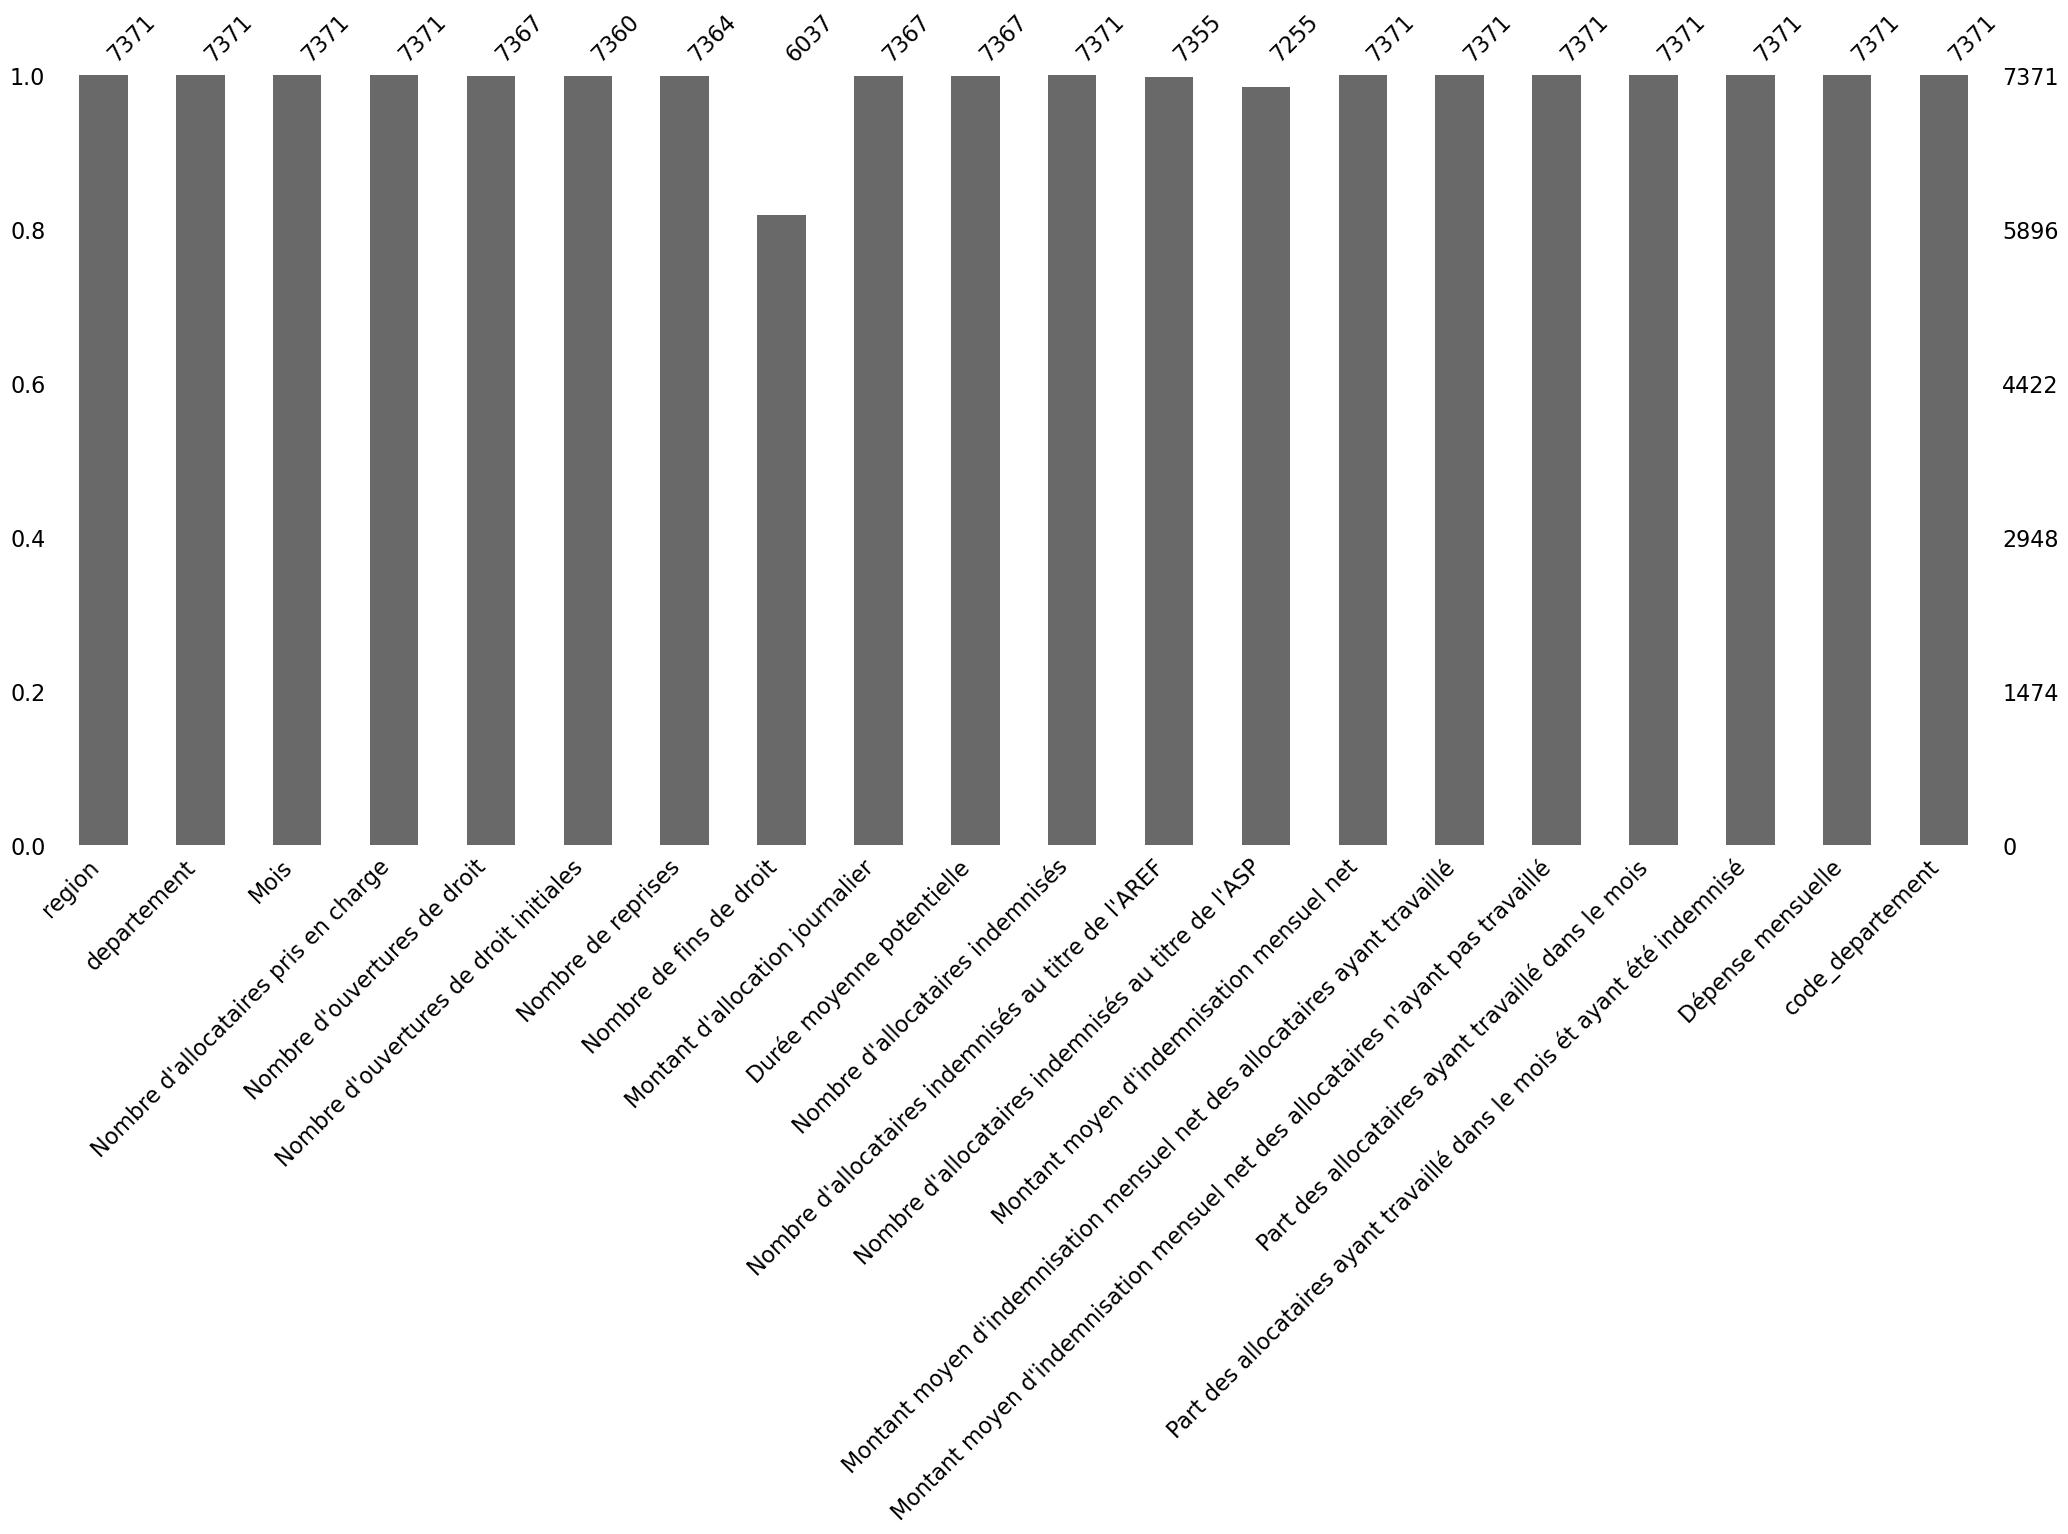

In [174]:
import missingno as msno
msno.bar(df)

In [175]:
missing_counts = df.isna().sum().sort_values(ascending=False) # check missing value
missing_counts

Nombre de fins de droit                                                             1334
Nombre d'allocataires indemnisés au titre de l'ASP                                   116
Nombre d'allocataires indemnisés au titre de l'AREF                                   16
Nombre d'ouvertures de droit initiales                                                11
Nombre de reprises                                                                     7
Nombre d'ouvertures de droit                                                           4
Montant d'allocation journalier                                                        4
Durée moyenne potentielle                                                              4
region                                                                                 0
Montant moyen d'indemnisation mensuel net des allocataires ayant travaillé             0
Dépense mensuelle                                                                      0
Part des allocataires

In [176]:
# Delete rows with NaN in columns with few missing values
missing_counts = df.isna().sum()
cols_to_dropna = missing_counts[missing_counts < 20].index
df = df.dropna(subset=cols_to_dropna)

In [177]:
# Hanlde rows with NaN in columns with many missing values
cols = missing_counts[missing_counts >= 20].index.tolist()
# Sort and interpolate by region+department, then close with median
df = df.sort_values(["region", "departement", "Mois"])
for c in cols:
    df[c] = (df.groupby(["region","departement"])[c]
               .transform(lambda s: s.interpolate(limit_direction="both")))
    df[c] = df[c].fillna(df[c].median())

/var/folders/j2/st7l9scn7yx12mlzqj137kj40000gn/T/ipykernel_52945/3190717244.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[c] = (df.groupby(["region","departement"])[c]


In [178]:
df.isna().sum()

region                                                                              0
departement                                                                         0
Mois                                                                                0
Nombre d'allocataires pris en charge                                                0
Nombre d'ouvertures de droit                                                        0
Nombre d'ouvertures de droit initiales                                              0
Nombre de reprises                                                                  0
Nombre de fins de droit                                                             0
Montant d'allocation journalier                                                     0
Durée moyenne potentielle                                                           0
Nombre d'allocataires indemnisés                                                    0
Nombre d'allocataires indemnisés au titre de l'AREF   

In [179]:
df.shape # after cleaning

(7344, 20)

In [180]:
df_cleaning = df.copy()

In [181]:
# save data_cleaning

df.to_csv('data_cleaned.csv', index=False)